# End-to-End VarNet MRI Reconstruction

This notebook demonstrates **End-to-End Variational Network (VarNet)** for 4x-accelerated multi-coil knee MRI reconstruction using pretrained weights from the fastMRI leaderboard.

Loads precomputed reference outputs — runs in seconds.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.visualization import compute_metrics, print_metrics

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Precomputed Results

In [2]:
DATA_DIR = os.path.join('..', 'data')
REF_DIR = os.path.join('..', 'evaluation', 'reference_outputs')

gt = np.load(os.path.join(DATA_DIR, 'ground_truth.npz'))['image'][0]
recon = np.load(os.path.join(REF_DIR, 'varnet_reconstruction.npz'))['reconstruction'][0]
zf = np.load(os.path.join(REF_DIR, 'zerofill.npz'))['reconstruction'][0]

print(f'Ground truth: {gt.shape}')
print(f'VarNet: {recon.shape}')
print(f'Zero-fill: {zf.shape}')

Ground truth: (320, 320)
VarNet: (320, 320)
Zero-fill: (320, 320)


## 2. Reconstruction Comparison

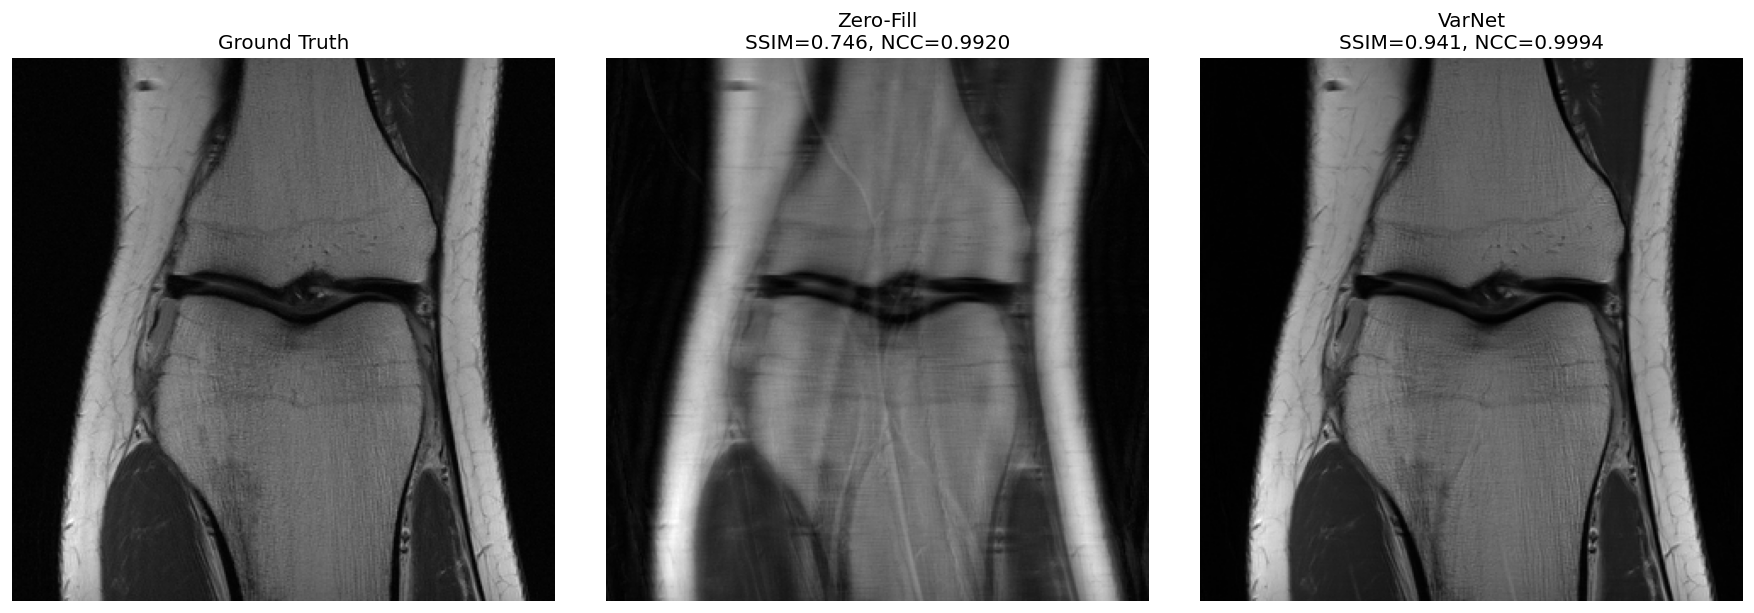

In [3]:
m_vn = compute_metrics(recon, gt)
m_zf = compute_metrics(zf, gt)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
    [gt, np.abs(zf), recon],
    ['Ground Truth',
     f'Zero-Fill\nSSIM={m_zf["ssim"]:.3f}, NCC={m_zf["ncc"]:.4f}',
     f'VarNet\nSSIM={m_vn["ssim"]:.3f}, NCC={m_vn["ncc"]:.4f}']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_83905/2762756181.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


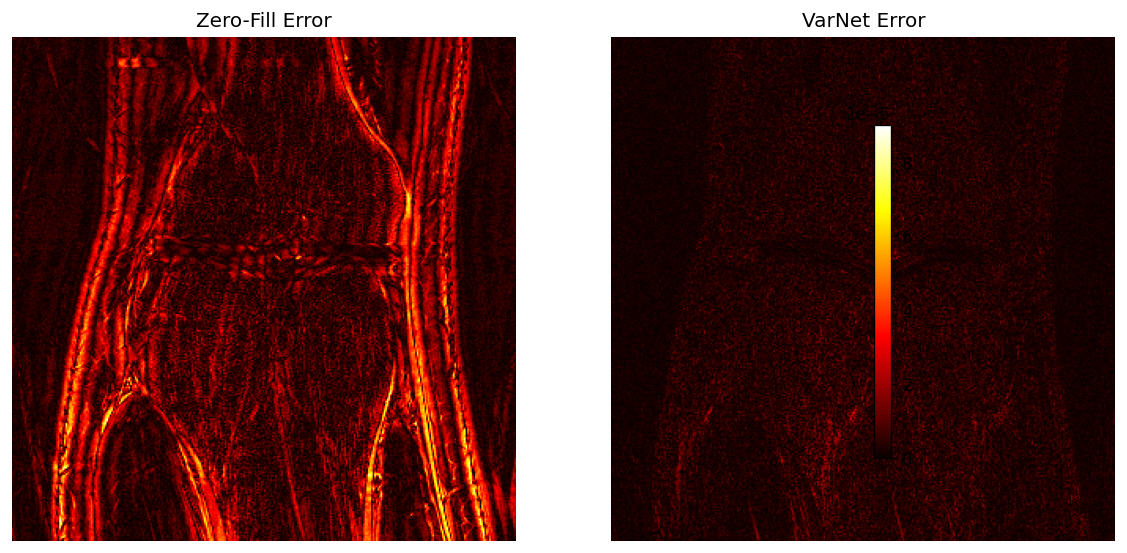

In [4]:
err_zf = np.abs(np.abs(zf) - gt)
err_vn = np.abs(recon - gt)
vmax = max(err_zf.max(), err_vn.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(err_zf, cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title('Zero-Fill Error'); axes[0].axis('off')
im = axes[1].imshow(err_vn, cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title('VarNet Error'); axes[1].axis('off')
plt.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Quantitative Metrics

In [5]:
print('=' * 50)
print('VarNet:')
print_metrics(m_vn)
print('\nZero-Fill:')
print_metrics(m_zf)
print('=' * 50)
print(f'\nSSIM improvement: {m_vn["ssim"] - m_zf["ssim"]:.3f}')
print(f'NRMSE reduction: {(1 - m_vn["nrmse"]/m_zf["nrmse"])*100:.1f}%')

VarNet:
  SSIM:  0.9411
  NCC:   0.9994
  NRMSE: 0.012703

Zero-Fill:
  SSIM:  0.7465
  NCC:   0.9920
  NRMSE: 0.045844

SSIM improvement: 0.195
NRMSE reduction: 72.3%


## 5. Run from Scratch (Optional)

In [6]:
# from src.preprocessing import prepare_data
# from src.solvers import load_varnet, varnet_reconstruct_batch
#
# kspace, gt_full, meta = prepare_data(os.path.join('..', 'data'))
# model = load_varnet(os.path.join('..', 'data', 'varnet_knee_state_dict.pt'))
# recons_new, zfs_new = varnet_reconstruct_batch(model, kspace, target_h=320, target_w=320)
# m = compute_metrics(recons_new[0], gt_full[0])
# print(f'SSIM={m["ssim"]:.4f}, NCC={m["ncc"]:.4f}')

## Conclusion

End-to-End VarNet achieves SSIM=0.941 from 4x-accelerated multi-coil k-space (vs 0.747 zero-fill), demonstrating the power of learned unrolled reconstruction with joint sensitivity estimation.